# Model of oscillation circuit

# Two interconnected LIF populations in NEST

In [1]:
import nest
#import nest.voltage_trace  # if you want quick membrane traces for select neurons
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Oct  2 2025 06:57:01

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
nest.ResetKernel()

### Parameters

In [3]:
params = {
    "N_exc": 2500,        # number of excitatory neurons
    "N_inh": 0,          # number of inhibitory neurons
    "p_ee": 0.00,        # E->E connection probability
    "J_exc": 55,         # excitatory weight (mV) for current-based LIF
    "delay_exc": 2,      # ms
    "delay_inh": 1,      # ms
    "tau_syn_ex": 2,     # ms
    "I_ext_exc": 0.0,    # pA external DC to E
    "t_sim": 120.0,       # ms
    "record_fraction": 0.05,  # fraction to record membrane potentials
    "seed": 42
}

# For reproducibility
nest.SetKernelStatus({
    "rng_seed": 42,
    "print_time": True,
    "overwrite_files": True
})

### Neuron model configuration

In [4]:
# Use current-based LIF ("iaf_psc_alpha") with distinct synaptic time constants
neuron_defaults = {
    "C_m": 250.0,          # pF
    "tau_m": 10.0,         # ms
    "t_ref": 2.0,          # ms
    "E_L": -70.0,          # mV
    "V_th": -55.0,         # mV
    "V_reset": -70.0,      # mV
    "tau_syn_ex": params["tau_syn_ex"],
}

nest.SetDefaults("iaf_psc_alpha", neuron_defaults)

### Create populations and inputs

In [5]:
exc = nest.Create("iaf_psc_alpha", params["N_exc"])

### Sinus drive

In [6]:
# --- Parameters for sinusoidal gamma drive ---
gamma_freq = 100.0   # Hz modulation frequency
base_rate = 80.0   # baseline rate
amplitude = 30.0   # modulation depth
n_generators = 3200   # number of sinusoidal sources

In [7]:
# --- Create multiple generators with jittered phases ---
phases = np.linspace(0, 2*np.pi, n_generators, endpoint=False)  # evenly spaced
jitter_percentage = 0.05
phase_jitter = np.random.normal(0, 2*np.pi*jitter_percentage, n_generators)           # small random jitter (radians)
phases = phases + phase_jitter

sin_gens = []
for phi in phases:
    g = nest.Create("sinusoidal_poisson_generator", 1, {
        "rate": base_rate,
        "amplitude": amplitude,
        "frequency": gamma_freq,
        "phase": phi
    })
    sin_gens.append(g[0])

# Connect each generator to excitatory neurons with fixed indegree
for g in sin_gens:
    nest.Connect(g, exc,
                 conn_spec={"rule": "pairwise_bernoulli", "p": 0.05},
                 syn_spec={"weight": 5, "delay": 1.0})


In [8]:
### recording spike generators
gen_recorders = nest.Create("spike_recorder", n_generators)

for g, rec in zip(sin_gens, gen_recorders):
    nest.Connect(g, rec)

## Synapse models

In [9]:
# Use static synapses with separate labels for E and I to set weights/delays
nest.CopyModel("static_synapse", "exc_syn", {"weight": params["J_exc"], "delay": params["delay_exc"]})
#nest.CopyModel("static_synapse", "inh_syn", {"weight": params["J_inh"], "delay": params["delay_inh"]})

### Connectivity

In [10]:
def connector(prob):
    return {
        "rule": "pairwise_bernoulli",
        "p": prob
    }

# E->E inside the green population
nest.Connect(exc, exc, connector(params["p_ee"]), syn_spec={"synapse_model": "exc_syn"})
#nest.Connect(exc, inh, connector(params["p_ei"]), syn_spec={"synapse_model": "exc_syn"})

### Recording

In [11]:
spike_rec_exc = nest.Create("spike_recorder")
nest.Connect(exc, spike_rec_exc)

# Population rate estimators (kernel-based rate)
rate_exc = nest.Create("spike_recorder", 1, {"record_to": "memory", "label": "rate_exc"})

nest.Connect(exc, rate_exc)

### Simulation

In [12]:
nest.Simulate(params["t_sim"])


Dec 01 14:08:06 NodeManager::prepare_nodes [Info]: 
    Preparing 8902 nodes for simulation.

Dec 01 14:08:06 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 8902
    Simulation time (ms): 120
    Number of OpenMP threads: 1
    Not using MPI

[ 100% ] Model time: 120.0 ms, Real-time factor: 103.0741

Dec 01 14:08:19 SimulationManager::run [Info]: 
    Simulation finished.


## Plotting

Exc spikes: 2753
Mean Exc firing rate (approx): 9.18 Hz


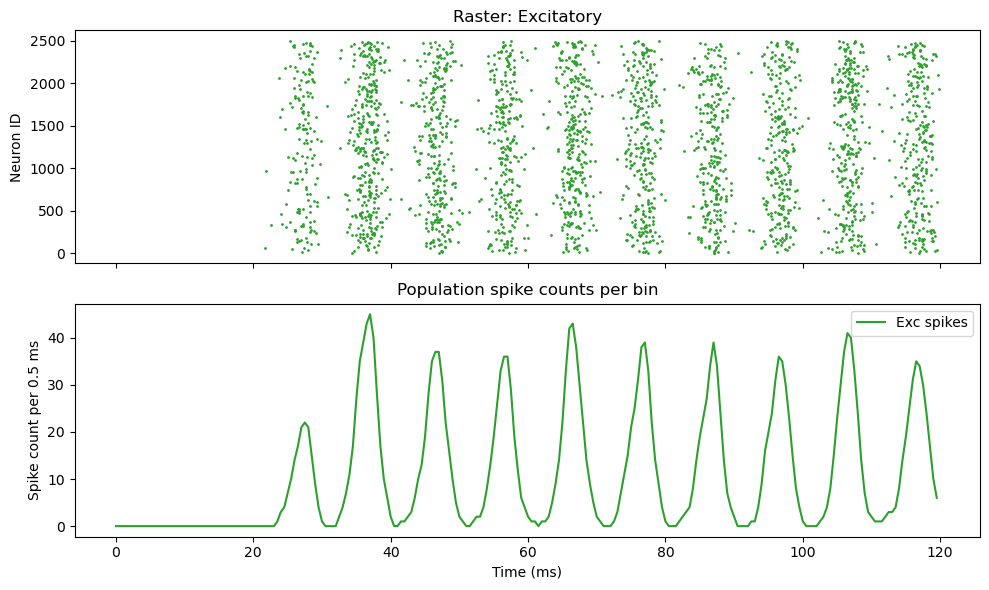

In [13]:
events_exc = nest.GetStatus(spike_rec_exc, "n_events")[0]
rate_exc_times = nest.GetStatus(rate_exc, "events")[0]["times"]
rate_exc_senders = nest.GetStatus(rate_exc, "events")[0]["senders"]

print(f"Exc spikes: {events_exc}")
print(f"Mean Exc firing rate (approx): {events_exc / params['N_exc'] / (params['t_sim']/1000):.2f} Hz")

# Optional quick plots (requires matplotlib)
try:
    # Raster
    exc_events = nest.GetStatus(spike_rec_exc, "events")[0]

    # Assume exc_events and inh_events are dicts from spike recorders
    exc_times = exc_events["times"]
    
    # Define binning
    bin_size = 0.5  # ms
    t_max = exc_times.max()
    bins = np.arange(0, t_max + bin_size, bin_size)
    
    # Histogram spike counts
    exc_counts, _ = np.histogram(exc_times, bins=bins)

    fig, ax = plt.subplots(2,1,figsize=(10, 6),sharex=True)

    ax[0].set_title("Raster: Excitatory")
    ax[0].scatter(exc_events["times"], exc_events["senders"], s=1, color="tab:green")
    ax[0].set_ylabel("Neuron ID")

    ax[1].set_title("Population spike counts per bin")
    ax[1].plot(bins[:-1], gaussian_filter1d(exc_counts,sigma=1), label="Exc spikes", color="tab:green")
    #ax[1].plot(bins[:-1], exc_counts, label="Exc spikes", color="tab:green")
    ax[1].set_xlabel("Time (ms)")
    ax[1].set_ylabel(f"Spike count per {bin_size} ms")
    ax[1].legend()

    plt.tight_layout()

    plt.show()
except ImportError:
    pass


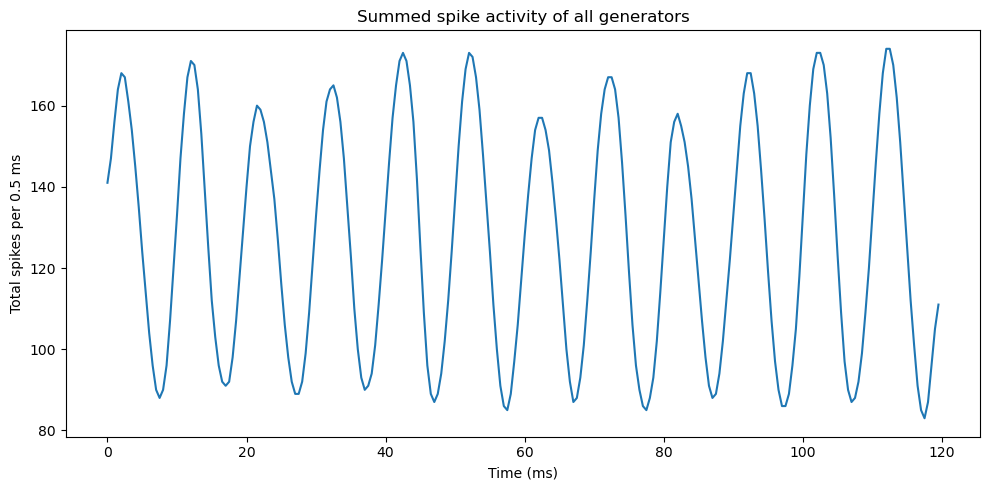

In [14]:
# Collect spikes from all generator recorders
all_times = []
for rec in gen_recorders:
    events = nest.GetStatus(rec, "events")[0]
    all_times.extend(events["times"])

# Convert to numpy array for convenience
all_times = np.array(all_times)

# Define binning
bin_size = 0.5  # ms
t_max = params["t_sim"]
bins = np.arange(0, t_max + bin_size, bin_size)

# Histogram: total spike count per bin across all generators
sine_counts, _ = np.histogram(all_times, bins=bins)

# Plot summed activity
plt.figure(figsize=(10,5))
plt.plot(bins[:-1], gaussian_filter1d(sine_counts,sigma=2), color="tab:blue")
plt.xlabel("Time (ms)")
plt.ylabel(f"Total spikes per {bin_size} ms")
plt.title("Summed spike activity of all generators")
plt.tight_layout()
plt.show()


In [15]:
def vec_norm(vec):
    #return (vec - vec.min()) / (vec.max() - vec.min())
    return vec / vec.max()

In [16]:
smooth = True
normalise = True
SIGMA = 1

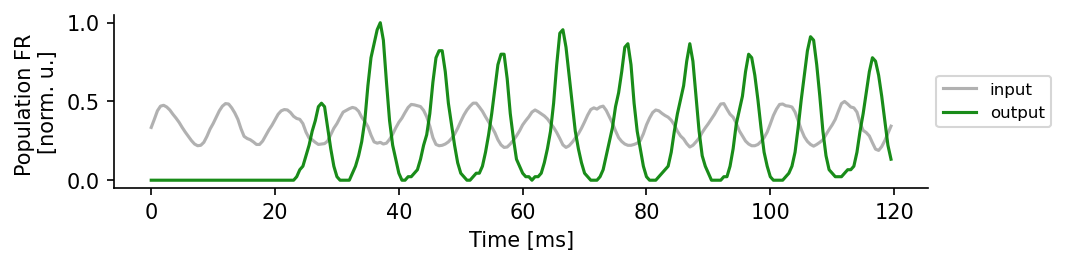

In [20]:
fig, ax = plt.subplots(figsize=(7,1.5),dpi=150)

input_spikes = sine_counts
exc_spikes = exc_counts

if smooth:
    input_spikes = gaussian_filter1d(input_spikes,sigma=SIGMA)
    exc_spikes = gaussian_filter1d(exc_spikes,sigma=SIGMA)

if normalise:
    input_spikes = vec_norm(input_spikes)
    exc_spikes = vec_norm(exc_spikes)

offset = 0
#ax.fill_between(bins[:-1],offset, offset+0.5*input_spikes, color="darkgray",alpha=0.6)
#ax.fill_between(bins[:-1], exc_spikes, color="green",alpha=0.6)
ax.plot(bins[:-1], offset+0.5*input_spikes, color="darkgray",alpha=0.9,label='input')
plt.plot(bins[:-1], exc_spikes, color="green",alpha=0.9,label='output')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Time [ms]')
ax.set_ylabel('Population FR \n[norm. u.]')

ax.legend(loc="center left",bbox_to_anchor=(1, 0.5),fontsize=8,ncol=1)
plt.show()
plt.close()